In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


In [4]:
df = pd.read_csv('Seasons_Stats.csv', index_col=0)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Year range: {int(df["Year"].min())} - {int(df["Year"].max())}')
print(f'Unique players: {df["Player"].nunique()}')
df.head()

Loaded: 20463 rows, 52 columns
Year range: 1950 - 2010
Unique players: 3382


,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,0.368,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,0.435,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,0.394,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,0.312,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,0.308,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


In [5]:
df = df[df['Year'] >= 1980].copy()
df = df.sort_values(['Player', 'Year', 'Tm'])
df = df.drop_duplicates(subset=['Player', 'Year'], keep='first')
df = df[df['G'] >= 20]

df['PPG']   = df['PTS'] / df['G']
df['RPG']   = df['TRB'] / df['G']
df['APG']   = df['AST'] / df['G']
df['SPG']   = df['STL'] / df['G']
df['BPG']   = df['BLK'] / df['G']
df['TOPG']  = df['TOV'] / df['G']
df['MPG']   = df['MP']  / df['G']
df['FPG']   = df['FG']  / df['G']
df['FAPG']  = df['FGA'] / df['G']
df['FTPG']  = df['FT']  / df['G']
df['FTAPG'] = df['FTA'] / df['G']
df['3PPG']  = df['3P']  / df['G']
df['3PAPG'] = df['3PA'] / df['G']

feature_cols = [
    'Age', 'G', 'MPG', 'PER', 'TS%', 'AST%', 'USG%',
    'OWS', 'DWS', 'WS', 'FPG', 'FAPG', 'FG%',
    '3PPG', '3PAPG', 'FTPG', 'FTAPG', 'FT%',
    'RPG', 'APG', 'SPG', 'BPG', 'TOPG', 'PPG'
]

df = df[['Player', 'Year'] + feature_cols].copy()
df[feature_cols] = df[feature_cols].fillna(0)

print(f'Cleaned dataset: {df.shape[0]} player-seasons')
df.head()

Cleaned dataset: 10118 player-seasons


,Player,Year,Age,G,MPG,PER,TS%,AST%,USG%,OWS,...,3PAPG,FTPG,FTAPG,FT%,RPG,APG,SPG,BPG,TOPG,PPG
8035,A.C. Green,1986.0,22.0,82.0,18.804878,11.8,0.564,4.2,14.7,1.4,...,0.073171,1.243902,2.036585,0.611,4.646341,0.658537,0.597561,0.597561,1.207317,6.353659
8420,A.C. Green,1987.0,23.0,79.0,28.354430,15.7,0.599,4.6,14.7,4.3,...,0.063291,2.784810,3.569620,0.780,7.784810,1.063291,0.886076,1.012658,1.291139,10.784810
8807,A.C. Green,1988.0,24.0,82.0,32.146341,14.5,0.581,4.5,14.7,4.5,...,0.024390,3.573171,4.621951,0.773,8.658537,1.134146,1.060976,0.548780,1.463415,11.426829
9242,A.C. Green,1989.0,25.0,82.0,30.609756,17.8,0.594,5.5,17.0,5.8,...,0.207317,3.439024,4.378049,0.786,9.012195,1.256098,1.146341,0.670732,1.451220,13.268293
9688,A.C. Green,1990.0,26.0,82.0,33.036585,14.7,0.548,4.6,17.1,4.4,...,0.560976,3.390244,4.512195,0.751,8.682927,1.097561,0.804878,0.609756,1.414634,12.939024


In [6]:
df = df.sort_values(['Player', 'Year']).reset_index(drop=True)

df['Next_Season_PPG'] = df.groupby('Player')['PPG'].shift(-1)
df['Next_Season_RPG'] = df.groupby('Player')['RPG'].shift(-1)
df['Next_Season_APG'] = df.groupby('Player')['APG'].shift(-1)
df['Next_Year']       = df.groupby('Player')['Year'].shift(-1)

df = df[df['Next_Year'] == df['Year'] + 1].copy()
df = df.drop(columns=['Next_Year'])
df = df.dropna(subset=['Next_Season_PPG', 'Next_Season_RPG', 'Next_Season_APG'])

print(f'Final dataset: {df.shape[0]} player-season pairs')
df[['Player','Year','PPG','RPG','APG','Next_Season_PPG','Next_Season_RPG','Next_Season_APG']].sort_values('PPG', ascending=False).head(10)

Final dataset: 7640 player-season pairs


,Player,Year,PPG,RPG,APG,Next_Season_PPG,Next_Season_RPG,Next_Season_APG
6744,Michael Jordan*,1987.0,37.085366,5.243902,4.597561,34.975610,5.475610,5.914634
5676,Kobe Bryant,2006.0,35.400000,5.312500,4.500000,31.558442,5.701299,5.363636
6745,Michael Jordan*,1988.0,34.975610,5.475610,5.914634,32.506173,8.049383,8.024691
6747,Michael Jordan*,1990.0,33.573171,6.890244,6.329268,31.463415,6.000000,5.524390
3541,George Gervin*,1980.0,33.141026,5.166667,2.589744,27.085366,5.109756,3.170732
207,Allen Iverson*,2006.0,33.013889,3.222222,7.388889,24.820000,3.040000,7.180000
6746,Michael Jordan*,1989.0,32.506173,8.049383,8.024691,33.573171,6.890244,6.329268
3543,George Gervin*,1982.0,32.291139,4.962025,2.367089,26.192308,4.576923,3.384615
9524,Tracy McGrady,2003.0,32.093333,6.506667,5.480000,28.029851,6.000000,5.522388
5677,Kobe Bryant,2007.0,31.558442,5.701299,5.363636,28.329268,6.304878,5.378049


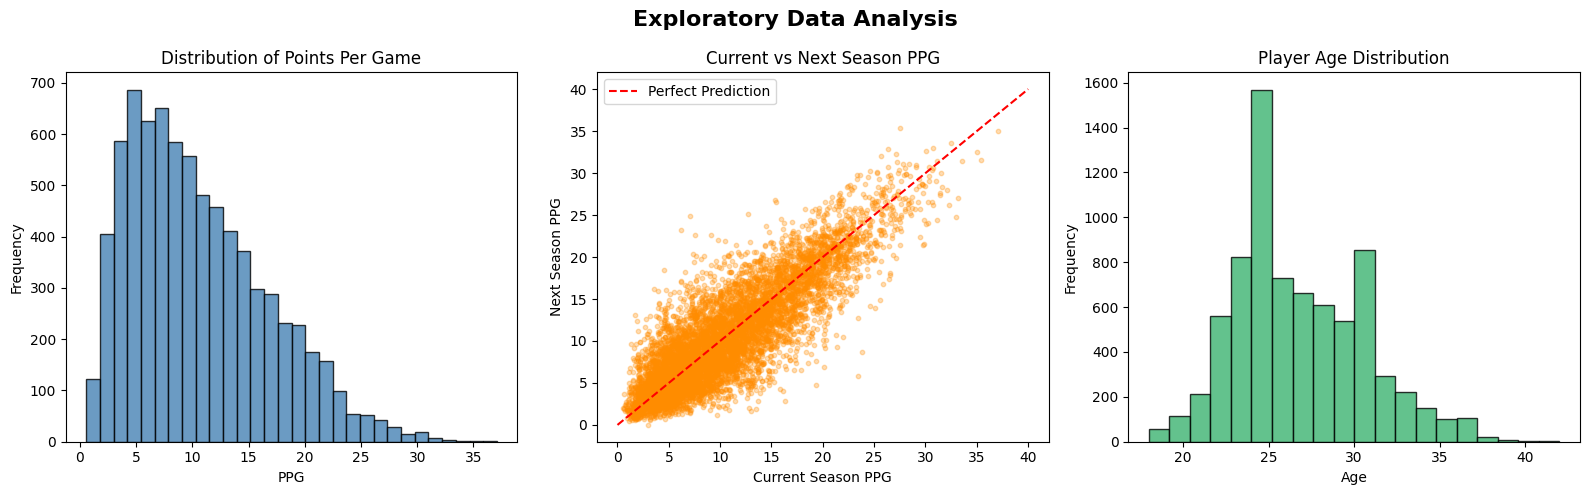

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

axes[0].hist(df['PPG'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Points Per Game')
axes[0].set_xlabel('PPG')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['PPG'], df['Next_Season_PPG'], alpha=0.3, color='darkorange', s=10)
axes[1].plot([0, 40], [0, 40], 'r--', label='Perfect Prediction')
axes[1].set_title('Current vs Next Season PPG')
axes[1].set_xlabel('Current Season PPG')
axes[1].set_ylabel('Next Season PPG')
axes[1].legend()

axes[2].hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Player Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

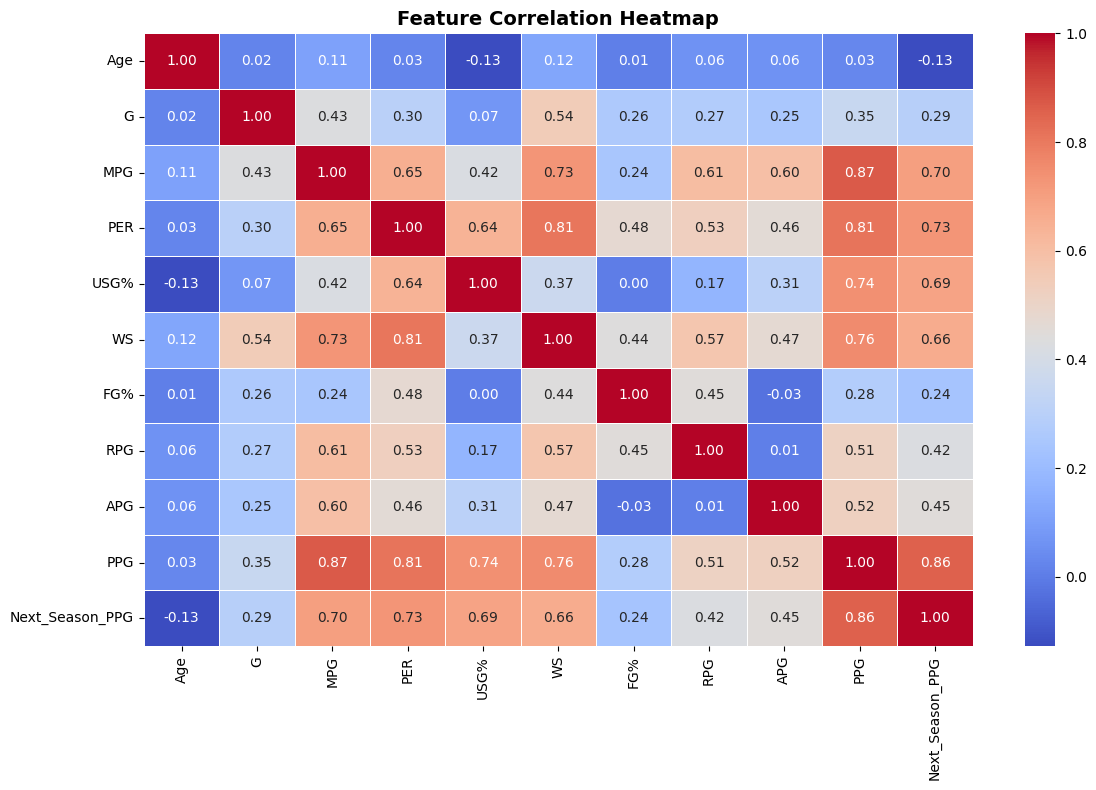

In [8]:
plt.figure(figsize=(12, 8))
corr_cols = ['Age','G','MPG','PER','USG%','WS','FG%','RPG','APG','PPG','Next_Season_PPG']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
X = df[feature_cols].values
y_ppg = df['Next_Season_PPG'].values
y_rpg = df['Next_Season_RPG'].values
y_apg = df['Next_Season_APG'].values


idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_train, X_test         = X[idx_train], X[idx_test]
y_train, y_test         = y_ppg[idx_train], y_ppg[idx_test]
y_train_rpg, y_test_rpg = y_rpg[idx_train], y_rpg[idx_test]
y_train_apg, y_test_apg = y_apg[idx_train], y_apg[idx_test]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 6112
Testing samples  : 1528
Features         : 24


In [10]:
print('Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)
print(f'MAE={lr_mae:.2f} ppg | RMSE={lr_rmse:.2f} ppg | R²={lr_r2:.4f}')

Training Linear Regression...
MAE=2.29 ppg | RMSE=2.97 ppg | R²=0.7781


In [11]:
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)
print(f'MAE={rf_mae:.2f} ppg | RMSE={rf_rmse:.2f} ppg | R²={rf_r2:.4f}')

Training Random Forest...
MAE=2.31 ppg | RMSE=2.98 ppg | R²=0.7766


In [12]:

print('Training RPG Model...')
rf_rpg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_rpg.fit(X_train, y_train_rpg)
rpg_preds = rf_rpg.predict(X_test)
rpg_mae = mean_absolute_error(y_test_rpg, rpg_preds)
rpg_r2  = r2_score(y_test_rpg, rpg_preds)
print(f'RPG → MAE={rpg_mae:.2f} | R²={rpg_r2:.4f}')


print('Training APG Model...')
rf_apg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_apg.fit(X_train, y_train_apg)
apg_preds = rf_apg.predict(X_test)
apg_mae = mean_absolute_error(y_test_apg, apg_preds)
apg_r2  = r2_score(y_test_apg, apg_preds)
print(f'APG → MAE={apg_mae:.2f} | R²={apg_r2:.4f}')

Training RPG Model...
RPG → MAE=0.95 | R²=0.7762
Training APG Model...
APG → MAE=0.62 | R²=0.7960


In [13]:
print('Training MLP Neural Network...')
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_s, y_train)
mlp_preds = mlp.predict(X_test_s)

mlp_mae  = mean_absolute_error(y_test, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))
mlp_r2   = r2_score(y_test, mlp_preds)
print(f'MAE={mlp_mae:.2f} ppg | RMSE={mlp_rmse:.2f} ppg | R²={mlp_r2:.4f}')

Training MLP Neural Network...
MAE=2.31 ppg | RMSE=3.02 ppg | R²=0.7712


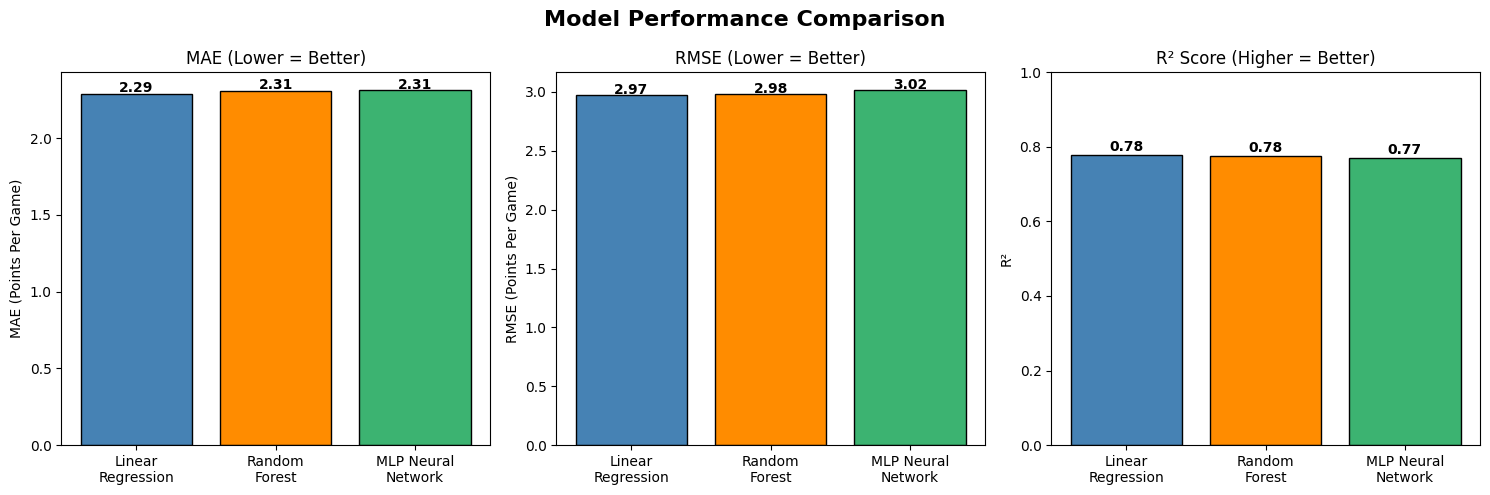

In [14]:
colors      = ['steelblue', 'darkorange', 'mediumseagreen']
model_names = ['Linear\nRegression', 'Random\nForest', 'MLP Neural\nNetwork']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, vals, title, ylabel in zip(
    axes,
    [[lr_mae,rf_mae,mlp_mae], [lr_rmse,rf_rmse,mlp_rmse], [lr_r2,rf_r2,mlp_r2]],
    ['MAE (Lower = Better)', 'RMSE (Lower = Better)', 'R² Score (Higher = Better)'],
    ['MAE (Points Per Game)', 'RMSE (Points Per Game)', 'R²']
):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if 'R²' in title:
        ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

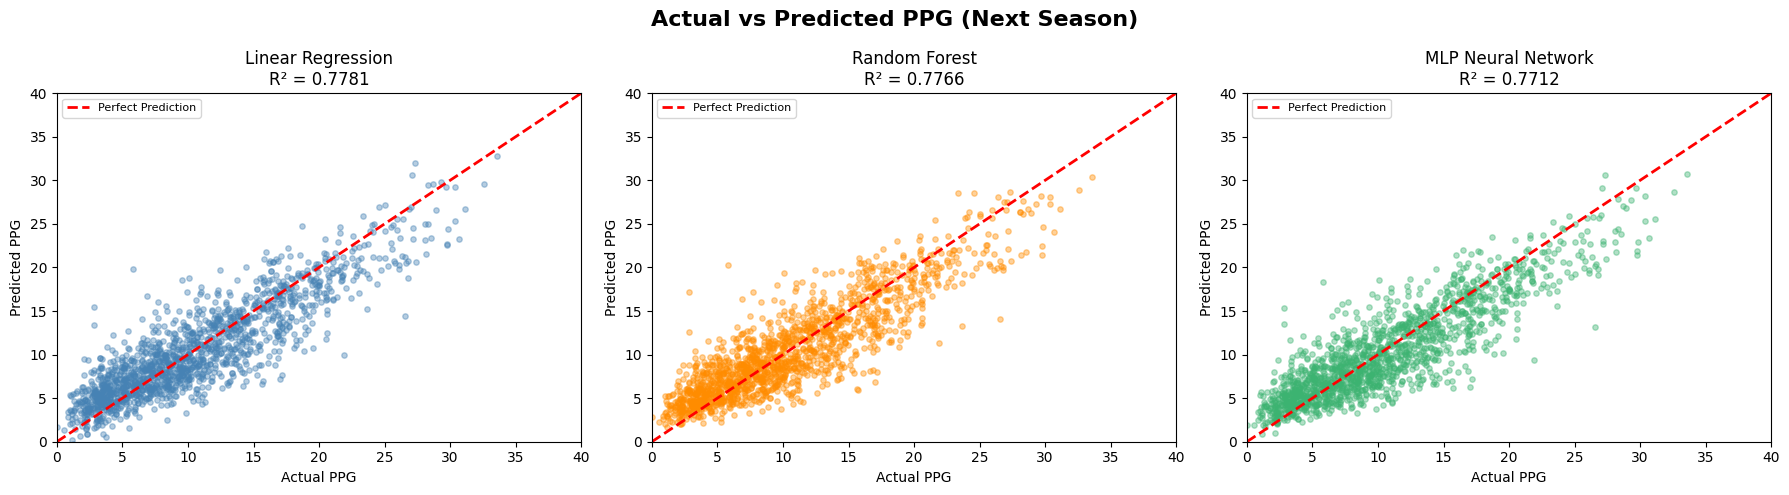

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs Predicted PPG (Next Season)', fontsize=16, fontweight='bold')

for i, (preds, title, r2) in enumerate(zip(
    [lr_preds, rf_preds, mlp_preds],
    ['Linear Regression', 'Random Forest', 'MLP Neural Network'],
    [lr_r2, rf_r2, mlp_r2]
)):
    axes[i].scatter(y_test, preds, alpha=0.4, color=colors[i], s=15)
    axes[i].plot([0, 40], [0, 40], 'r--', linewidth=2, label='Perfect Prediction')
    axes[i].set_title(f'{title}\nR² = {r2:.4f}')
    axes[i].set_xlabel('Actual PPG')
    axes[i].set_ylabel('Predicted PPG')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 40)
    axes[i].set_ylim(0, 40)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

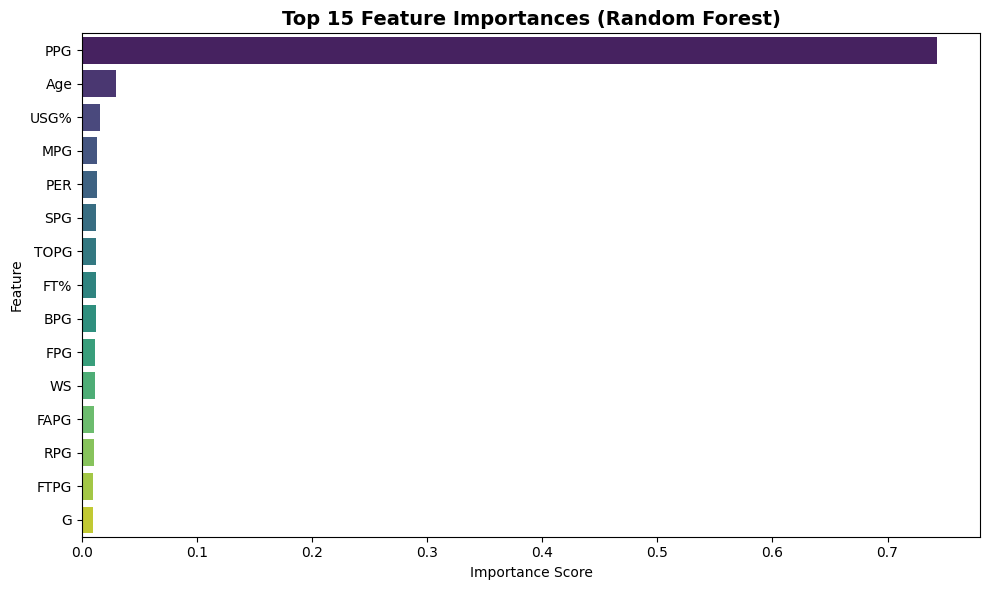

In [16]:
feat_imp = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

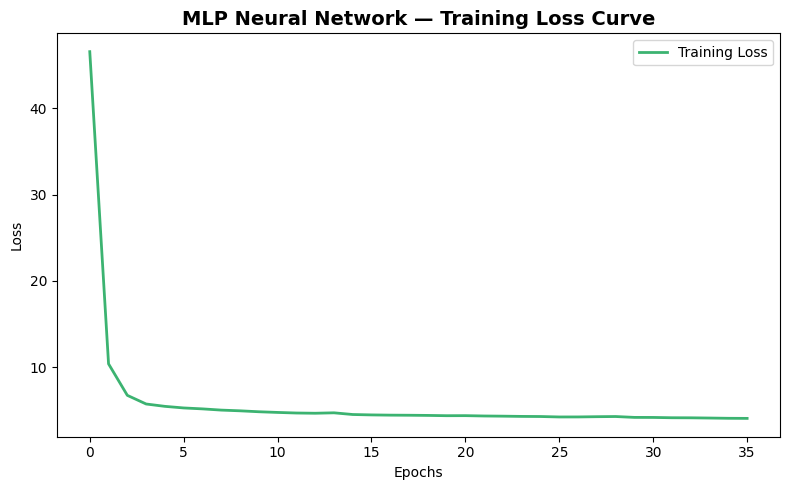

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='mediumseagreen', linewidth=2, label='Training Loss')
plt.title('MLP Neural Network — Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
sample_out = df.iloc[idx_test][['Player', 'Year', 'PPG', 'Next_Season_PPG']].copy()
sample_out.columns = ['Player', 'Year', 'This_Season_PPG', 'Actual_Next_PPG']
sample_out['LR_Pred']  = lr_preds.round(1)
sample_out['RF_Pred']  = rf_preds.round(1)
sample_out['MLP_Pred'] = mlp_preds.round(1)

print('Sample Predictions — Players with 20+ PPG:')
print(sample_out[sample_out['This_Season_PPG'] >= 20]
      .sort_values('This_Season_PPG', ascending=False)
      .head(15).to_string(index=False))

print(f'\n{"="*55}')
print(f'         PLAYERPREDICT AI — COMPLETE')
print(f'{"="*55}')
print(f'Linear Regression  → MAE={lr_mae:.2f} | RMSE={lr_rmse:.2f} | R²={lr_r2:.4f}')
print(f'Random Forest      → MAE={rf_mae:.2f} | RMSE={rf_rmse:.2f} | R²={rf_r2:.4f}')
print(f'MLP Neural Network → MAE={mlp_mae:.2f} | RMSE={mlp_rmse:.2f} | R²={mlp_r2:.4f}')

Sample Predictions — Players with 20+ PPG:
           Player   Year  This_Season_PPG  Actual_Next_PPG  LR_Pred  RF_Pred  MLP_Pred
   George Gervin* 1980.0        33.141026        27.085366     30.6     27.5      29.1
  Michael Jordan* 1989.0        32.506173        33.573171     32.7     30.4      30.7
      Kobe Bryant 2007.0        31.558442        28.329268     29.5     27.7      27.8
     LeBron James 2006.0        31.367089        27.333333     32.0     28.6      30.6
  Adrian Dantley* 1981.0        30.650000        30.333333     29.2     28.1      28.2
  Michael Jordan* 1996.0        30.378049        29.646341     29.2     28.2      29.1
  Michael Jordan* 1992.0        30.050000        32.576923     29.5     28.9      28.6
Shaquille O'Neal* 2000.0        29.670886        28.716216     29.6     26.7      27.1
Shaquille O'Neal* 1994.0        29.345679        29.303797     29.8     27.3      27.8
    Alex English* 1987.0        28.597561        25.000000     24.2     25.9      23.0


In [19]:
def predict_player(name):
    matches = df[df['Player'].str.contains(name, case=False, na=False)]
    if matches.empty:
        print(f'Player "{name}" not found.')
        return

    row = matches.iloc[-1]
    X_input = np.array(row[feature_cols].values).reshape(1, -1)


    ppg_trees = np.array([tree.predict(X_input)[0] for tree in rf.estimators_])
    ppg_mean, ppg_std = ppg_trees.mean(), ppg_trees.std()


    rpg_trees = np.array([tree.predict(X_input)[0] for tree in rf_rpg.estimators_])
    rpg_mean, rpg_std = rpg_trees.mean(), rpg_trees.std()


    apg_trees = np.array([tree.predict(X_input)[0] for tree in rf_apg.estimators_])
    apg_mean, apg_std = apg_trees.mean(), apg_trees.std()

    print(f"\n🏀 PlayerPredict AI — {row['Player']} ({int(row['Year'])} Season)")
    print(f"  Predicted Next Season PPG: {ppg_mean:.1f} ± {ppg_std:.1f}")
    print(f"  Predicted Next Season RPG: {rpg_mean:.1f} ± {rpg_std:.1f}")
    print(f"  Predicted Next Season APG: {apg_mean:.1f} ± {apg_std:.1f}")


predict_player('LeBron')
predict_player('Kobe')
predict_player('Michael Jordan')


🏀 PlayerPredict AI — LeBron James (2009 Season)
  Predicted Next Season PPG: 28.4 ± 2.4
  Predicted Next Season RPG: 7.4 ± 0.7
  Predicted Next Season APG: 7.8 ± 1.1

🏀 PlayerPredict AI — Kobe Bryant (2009 Season)
  Predicted Next Season PPG: 26.5 ± 1.9
  Predicted Next Season RPG: 5.2 ± 0.5
  Predicted Next Season APG: 4.9 ± 0.5

🏀 PlayerPredict AI — Michael Jordan* (2002 Season)
  Predicted Next Season PPG: 19.7 ± 5.4
  Predicted Next Season RPG: 4.4 ± 1.4
  Predicted Next Season APG: 4.8 ± 1.2


In [20]:
import gradio as gr

FEATURE_LABELS = {
    'Age': 'Age',
    'G': 'Games',
    'MPG': 'Minutes / game',
    'PER': 'PER',
    'TS%': 'True shooting %',
    'AST%': 'Assist %',
    'USG%': 'Usage %',
    'OWS': 'Off. win shares',
    'DWS': 'Def. win shares',
    'WS': 'Win shares',
    'FPG': 'FG made / game',
    'FAPG': 'FG attempts / game',
    'FG%': 'Field goal %',
    '3PPG': '3P made / game',
    '3PAPG': '3P attempts / game',
    'FTPG': 'FT made / game',
    'FTAPG': 'FT attempts / game',
    'FT%': 'Free throw %',
    'RPG': 'Rebounds / game',
    'APG': 'Assists / game',
    'SPG': 'Steals / game',
    'BPG': 'Blocks / game',
    'TOPG': 'Turnovers / game',
    'PPG': 'Points / game',
}

latest = df.sort_values('Year').tail(min(500, len(df)))
feature_defaults = {col: round(float(latest[col].median()), 3) for col in feature_cols}
player_rows = df[['Player', 'Year'] + feature_cols + ['Next_Season_PPG']].copy()
player_rows = player_rows.sort_values(['Player', 'Year'], ascending=[True, False])

sample_table = sample_out[sample_out['This_Season_PPG'] >= 20].sort_values(
    'This_Season_PPG', ascending=False
).head(10)
sample_table = sample_table.rename(
    columns={
        'This_Season_PPG': 'This PPG',
        'Actual_Next_PPG': 'Actual Next',
        'RF_Pred': 'RF Pred',
    }
)[['Player', 'Year', 'This PPG', 'Actual Next', 'RF Pred']]

metric_rows = pd.DataFrame(
    [
        {'Model': 'Linear Regression', 'MAE': round(lr_mae, 2), 'RMSE': round(lr_rmse, 2), 'R2': round(lr_r2, 3)},
        {'Model': 'Random Forest', 'MAE': round(rf_mae, 2), 'RMSE': round(rf_rmse, 2), 'R2': round(rf_r2, 3)},
        {'Model': 'MLP Neural Network', 'MAE': round(mlp_mae, 2), 'RMSE': round(mlp_rmse, 2), 'R2': round(mlp_r2, 3)},
    ]
)


def render_metric_cards():
    return ''.join(
        f"""
        <article class="metric-card">
            <div class="metric-name">{row.Model}</div>
            <div class="metric-main">{row.MAE:.2f}<span> MAE</span></div>
            <div class="metric-grid">
                <span>RMSE <b>{row.RMSE:.2f}</b></span>
                <span>R2 <b>{row.R2:.3f}</b></span>
            </div>
        </article>
        """
        for row in metric_rows.itertuples()
    )


def render_importance():
    items = feat_imp.head(12).copy()
    max_value = float(items['Importance'].max()) or 1.0
    return ''.join(
        f"""
        <div class="bar-row">
            <span>{FEATURE_LABELS.get(row.Feature, row.Feature)}</span>
            <div class="bar-track"><div style="width: {float(row.Importance) / max_value * 100:.1f}%"></div></div>
            <b>{float(row.Importance):.3f}</b>
        </div>
        """
        for row in items.itertuples()
    )


def predict_from_values(*values):
    X_input = np.array(values, dtype=float).reshape(1, -1)
    X_scaled = scaler.transform(X_input)

    lr_pred = float(lr.predict(X_scaled)[0])
    rf_pred = float(rf.predict(X_input)[0])
    mlp_pred = float(mlp.predict(X_scaled)[0])

    ppg_trees = np.array([tree.predict(X_input)[0] for tree in rf.estimators_])
    rpg_trees = np.array([tree.predict(X_input)[0] for tree in rf_rpg.estimators_])
    apg_trees = np.array([tree.predict(X_input)[0] for tree in rf_apg.estimators_])

    return f"""
    <div class="prediction-box">
        <small>Random Forest prediction</small>
        <div class="prediction-value">{rf_pred:.2f} PPG</div>
        <div class="mini-preds">
            <div><small>Linear Regression</small><br><b>{lr_pred:.2f}</b></div>
            <div><small>Random Forest</small><br><b>{rf_pred:.2f}</b></div>
            <div><small>MLP Neural Network</small><br><b>{mlp_pred:.2f}</b></div>
        </div>
        <div class="mini-preds">
            <div><small>PPG uncertainty</small><br><b>{ppg_trees.mean():.1f} +/- {ppg_trees.std():.1f}</b></div>
            <div><small>RPG forecast</small><br><b>{rpg_trees.mean():.1f} +/- {rpg_trees.std():.1f}</b></div>
            <div><small>APG forecast</small><br><b>{apg_trees.mean():.1f} +/- {apg_trees.std():.1f}</b></div>
        </div>
    </div>
    """


def search_players(query):
    rows = player_rows
    if query:
        rows = rows[rows['Player'].str.contains(query, case=False, na=False)]
    choices = [
        f"{row.Player} ({int(row.Year)})"
        for row in rows.head(25).itertuples()
    ]
    value = choices[0] if choices else None
    return gr.update(choices=choices, value=value)


def load_player(label):
    if not label:
        return [gr.update()] * len(feature_cols)

    player_name, year_part = label.rsplit(' (', 1)
    year = int(year_part.rstrip(')'))
    match = player_rows[(player_rows['Player'] == player_name) & (player_rows['Year'] == year)]
    if match.empty:
        return [gr.update()] * len(feature_cols)

    row = match.iloc[0]
    return [float(row[col]) for col in feature_cols]


with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="slate",
        neutral_hue="slate",
        font=gr.themes.GoogleFont("Inter")

    ),
    css="""


        }
        .gradio-container {
            max-width: none !important;
            padding: 0 !important;
            color: #18212f;
            background: #f3f6fa;
        }
        footer { visibility: hidden !important; }
        #app-shell {
            width: min(1220px, calc(100% - 32px));
            margin: 24px auto 48px;
        }
        #site-header {
            background: #111827;
            color: white;
            padding: 28px clamp(18px, 4vw, 48px);
            border-bottom: 4px solid #c58a16;
        }
        #site-header h1 {
            margin: 0 0 8px;
            font-size: clamp(28px, 4vw, 48px);
            letter-spacing: 0;
            color: white;
        }
        #site-header p {
            margin: 0;
            color: #cbd5e1;
            max-width: 760px;
            line-height: 1.5;
        }
        .status-panel {
            display: flex;
            justify-content: space-between;
            gap: 18px;
            align-items: center;
            padding: 14px 16px;
            border: 1px solid #d7dde6;
            background: white;
            border-left: 5px solid #0f7b6c;
            border-radius: 8px;
            margin-bottom: 18px;
        }
        .status-panel strong { display: block; }
        .status-panel span { color: #687386; }
        .stats-grid, .metrics-grid {
            display: grid;
            grid-template-columns: repeat(4, minmax(0, 1fr));
            gap: 12px;
            margin: 18px 0;
        }
        .metrics-grid { grid-template-columns: repeat(3, minmax(0, 1fr)); }
        .stats-grid div, .metric-card, .panel-card {
            background: white;
            border: 1px solid #d7dde6;
            border-radius: 8px;
        }
        .stats-grid div { padding: 16px; }
        .stats-grid b { display: block; font-size: 24px; }
        .stats-grid span, .muted { color: #687386; }
        .metric-card { padding: 16px; }
        .metric-name { color: #687386; font-weight: 700; }
        .metric-main { font-size: 34px; font-weight: 800; margin: 10px 0; }
        .metric-main span { color: #687386; font-size: 14px; font-weight: 700; }
        .metric-grid { display: flex; gap: 14px; color: #687386; }
        .panel-card { padding: 18px; }
        .panel-card h2 { font-size: 19px; margin: 0 0 14px; }
        .form-grid {
            max-height: 520px;
            overflow: auto;
            padding-right: 4px;
        }
        .prediction-box {
            margin-top: 16px;
            padding: 16px;
            border-radius: 8px;
            background: white;
            border: 1px solid #d7dde6;
            color: #18212f !important;
        }
        .prediction-box * {
            color: #18212f !important;
        }
        .prediction-box small {
            color: #687386 !important;
        }
        .prediction-value {
            font-size: 44px;
            font-weight: 900;
        }
        .mini-preds {
            display: grid;
            grid-template-columns: repeat(3, minmax(0, 1fr));
            gap: 8px;
            margin-top: 12px;
        }
        .mini-preds div {
            border: 1px solid #d7dde6;
            border-radius: 7px;
            padding: 9px;
        }

        /* Dark mode overrides */
        .dark .prediction-box {
            background: #132033;
            border-color: #132033;
            color: white !important;
        }
        .dark .prediction-box * {
            color: white !important;
        }
        .dark .prediction-box small {
            color: #cbd5e1 !important;
        }
        .dark .mini-preds div {
            border-color: rgba(255,255,255,.18);
        }
        .bar-row {
            display: grid;
            grid-template-columns: 150px 1fr 54px;
            gap: 10px;
            align-items: center;
            margin: 10px 0;
            font-size: 14px;
        }
        .bar-track {
            height: 12px;
            background: #e8edf4;
            border-radius: 999px;
            overflow: hidden;
        }
        .bar-track div { height: 100%; background: #0f7b6c; }
        #plots-row img {
            border: 1px solid #d7dde6;
            border-radius: 6px;
            background: white;
        }

        .dark .gradio-container input,
        .dark .gradio-container textarea,
        .dark .gradio-container select {
            background: #1f2937 !important;
            color: #f3f4f6 !important;
            border-color: #374151 !important;
        }
        .dark .gradio-container label span,
        .dark .gradio-container .panel-card h2 {
            color: #f3f4f6 !important;
        }
        .dark .panel-card,
        .dark .metric-card,
        .dark .stats-grid div,
        .dark .status-panel {
            background: #1f2937 !important;
            border-color: #374151 !important;
            color: #e5e7eb !important;
        }
        .dark .metric-name,
        .dark .metric-grid,
        .dark .stats-grid span,
        .dark .muted,
        .dark .status-panel span {
            color: #9ca3af !important;
        }

        @media (max-width: 900px) {
            .stats-grid, .metrics-grid, .mini-preds { grid-template-columns: 1fr; }
            .status-panel { align-items: flex-start; flex-direction: column; }
        }
    """
) as app:

    gr.HTML("""
        <header id="site-header">
            <h1>NBA Player Performance Prediction</h1>
            <p>Predict next-season points, rebounds, and assists from player season stats, compare model accuracy, and inspect the Random Forest feature signal.</p>
        </header>
    """)

    with gr.Column(elem_id="app-shell"):
        gr.HTML(f"""
            <section class="status-panel">
                <div>
                    <strong>Ready</strong>
                    <span>Model trained and ready.</span>
                </div>
            </section>
            <section class="stats-grid">
                <div><b>{len(df):,}</b><span>player seasons</span></div>
                <div><b>{df['Player'].nunique():,}</b><span>players</span></div>
                <div><b>{int(df['Year'].min())}-{int(df['Year'].max())}</b><span>seasons</span></div>
                <div><b>{len(feature_cols)}</b><span>features</span></div>
            </section>
            <section class="metrics-grid">{render_metric_cards()}</section>
        """)

        with gr.Row():
            with gr.Column(scale=4, elem_classes=["panel-card"]):
                gr.HTML("<h2>Prediction Input</h2>")
                with gr.Row():
                    player_search = gr.Textbox(
                        label=None,
                        placeholder="Search player seasons",
                        show_label=False,
                        scale=3,
                    )
                    search_button = gr.Button("Search", scale=1)
                player_select = gr.Dropdown(
                    choices=[f"{row.Player} ({int(row.Year)})" for row in player_rows.head(12).itertuples()],
                    label="Player seasons",
                    interactive=True,
                )
                with gr.Column(elem_classes=["form-grid"]):
                    feature_inputs = [
                        gr.Number(
                            value=feature_defaults[col],
                            label=FEATURE_LABELS[col],
                            precision=3,
                        )
                        for col in feature_cols
                    ]
                predict_button = gr.Button("Predict next stats", variant="primary")
                prediction_output = gr.HTML(value=predict_from_values(*[feature_defaults[col] for col in feature_cols]))

            with gr.Column(scale=6):
                with gr.Column(elem_classes=["panel-card"]):
                    gr.HTML(f"<h2>Top Feature Importance</h2>{render_importance()}")
                with gr.Column(elem_classes=["panel-card"]):
                    gr.HTML("<h2>High-Scoring Test Samples</h2>")
                    gr.DataFrame(
                        value=sample_table,
                        interactive=False,
                        wrap=True,
                        label=None,
                    )

        with gr.Row(elem_id="plots-row"):
            gr.Image(value="eda_plots.png", label="Exploratory Data Analysis", interactive=False)
            gr.Image(value="correlation_heatmap.png", label="Feature Correlation Heatmap", interactive=False)
        with gr.Row(elem_id="plots-row"):
            gr.Image(value="model_comparison.png", label="Model Performance Comparison", interactive=False)
            gr.Image(value="actual_vs_predicted.png", label="Actual vs Predicted PPG", interactive=False)
        with gr.Row(elem_id="plots-row"):
            gr.Image(value="feature_importance.png", label="Top 15 Feature Importances", interactive=False)
            gr.Image(value="mlp_loss_curve.png", label="MLP Training Loss Curve", interactive=False)

    search_button.click(
        fn=search_players,
        inputs=player_search,
        outputs=player_select,
    )
    player_search.submit(
        fn=search_players,
        inputs=player_search,
        outputs=player_select,
    )
    player_select.change(
        fn=load_player,
        inputs=player_select,
        outputs=feature_inputs,
    ).then(
        fn=predict_from_values,
        inputs=feature_inputs,
        outputs=prediction_output,
    )
    predict_button.click(
        fn=predict_from_values,
        inputs=feature_inputs,
        outputs=prediction_output,
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cd32f53ad037118b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
